In [1]:
!pip install timm

In [2]:
!pip install -U torchmetrics
!pip install -U torch-fidelity
!pip install "torchmetrics[image]"

In [3]:
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

In [4]:
DATA_DIR = "/home/fadiba/rse/1400"
BATCH_SIZE = 16
LATENT_DIM = 64
EPOCHS = 1000
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
class TiffDataset(Dataset):
    def __init__(self, folder):
        self.files = sorted(
            glob.glob(os.path.join(folder, "*.tif")) +
            glob.glob(os.path.join(folder, "*.tiff"))
        )
        self.transform_dino = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),  # DINO expects 3 channels
            transforms.ToTensor(),
        ])
        self.transform_target = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")


        #getting the original width and height
        w, h = img.size

        #to ensure the image is actually taller than 62 pixels before cropping
        if h > 62:
            # Crop takes (left, top, right, bottom)
            # We keep from 0 to w (width) and 0 to (h - 62) (height without the panel)
            img = img.crop((0, 0, w, h - 62))
       

        x_dino = self.transform_dino(img)     # [3,224,224]
        x_target = self.transform_target(img) # [1,64,64]
        return x_dino, x_target

In [6]:
dataset = TiffDataset(DATA_DIR)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [7]:

#loading DINOv2 encoder

dino = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dino.eval().to(DEVICE)

for p in dino.parameters():
    p.requires_grad = False

# figure out DINO embedding dim
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    dummy_feat = dino(dummy)
    DINO_DIM = dummy_feat.shape[-1]

print("DINO embedding dim:", DINO_DIM)

Using cache found in /home/fadiba/.cache/torch/hub/facebookresearch_dinov2_main
/home/fadiba/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/fadiba/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/fadiba/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINO embedding dim: 384


In [8]:
# VAE on top of DINO features
class DinoVAE(nn.Module):
    def __init__(self, dino_dim=DINO_DIM, latent_dim=LATENT_DIM):
        super().__init__()

        # VAE encoder from DINO features -> latent params
        self.fc_mu = nn.Sequential(
            nn.Linear(dino_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        self.fc_logvar = nn.Sequential(
            nn.Linear(dino_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

        # latent -> image decoder
        self.decoder_input = nn.Linear(latent_dim, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),    # 64x64
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def encode(self, feat):
        mu = self.fc_mu(feat)
        logvar = self.fc_logvar(feat)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 256, 8, 8)
        return self.decoder(x)

    def forward(self, feat):
        mu, logvar = self.encode(feat)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

model = DinoVAE().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [40]:
def vae_loss(recon, target, mu, logvar, beta=2e-2):
    #recon_loss = F.mse_loss(recon, target, reduction="mean")
    recon_loss = F.l1_loss(recon, target, reduction="mean") #for enhancing the edge detection
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=100
)

lr_history = []
loss_history = []

In [54]:
# Training
#increasing beta : 1e-3, 2e-3, 5e-3, 1e-2,5e-2
beta_max = 2e-2
warmup_epochs = 100

loss_history = []
recon_history = []
kl_history = []
beta_history = []
lr_history = []


for epoch in range(EPOCHS):
    model.train()

    running_total = 0.0
    running_recon = 0.0
    running_kl = 0.0
    num_batches = 0

    # KL warmup
    beta = min(beta_max, ((epoch + 1) / warmup_epochs) * beta_max)
    beta_history.append(beta)

    for x_dino, x_target in loader:
        x_dino = x_dino.to(DEVICE)
        x_target = x_target.to(DEVICE)

        # frozen DINO features
        with torch.no_grad():
            feat = dino(x_dino)

        # forward pass
        recon, mu, logvar = model(feat)

        # compute total + separate losses
        total_loss, recon_loss, kl_loss = vae_loss(
            recon, x_target, mu, logvar, beta=beta
        )

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_total += total_loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_loss.item()
        num_batches += 1

    # epoch averages
    avg_total = running_total / num_batches
    avg_recon = running_recon / num_batches
    avg_kl = running_kl / num_batches

    loss_history.append(avg_total)
    recon_history.append(avg_recon)
    kl_history.append(avg_kl)

    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Total: {avg_total:.6f} | "
        f"Recon: {avg_recon:.6f} | "
        f"KL: {avg_kl:.6f} | "
        f"Beta: {beta:.6f} | "
        f"LR: {current_lr:.6e}"
    )

Epoch [1/1000] | Total: 0.013031 | Recon: 0.012885 | KL: 0.730536 | Beta: 0.000200 | LR: 1.000000e-03
Epoch [2/1000] | Total: 0.011528 | Recon: 0.010989 | KL: 1.345544 | Beta: 0.000400 | LR: 9.997533e-04
Epoch [3/1000] | Total: 0.011155 | Recon: 0.010203 | KL: 1.586900 | Beta: 0.000600 | LR: 9.990134e-04
Epoch [4/1000] | Total: 0.010879 | Recon: 0.009669 | KL: 1.512644 | Beta: 0.000800 | LR: 9.977810e-04
Epoch [5/1000] | Total: 0.010800 | Recon: 0.009412 | KL: 1.388433 | Beta: 0.001000 | LR: 9.960574e-04
Epoch [6/1000] | Total: 0.010832 | Recon: 0.009281 | KL: 1.292429 | Beta: 0.001200 | LR: 9.938442e-04
Epoch [7/1000] | Total: 0.011208 | Recon: 0.009533 | KL: 1.196820 | Beta: 0.001400 | LR: 9.911436e-04
Epoch [8/1000] | Total: 0.011333 | Recon: 0.009520 | KL: 1.132713 | Beta: 0.001600 | LR: 9.879584e-04
Epoch [9/1000] | Total: 0.011555 | Recon: 0.009574 | KL: 1.100615 | Beta: 0.001800 | LR: 9.842916e-04
Epoch [10/1000] | Total: 0.011469 | Recon: 0.009341 | KL: 1.064333 | Beta: 0.00200

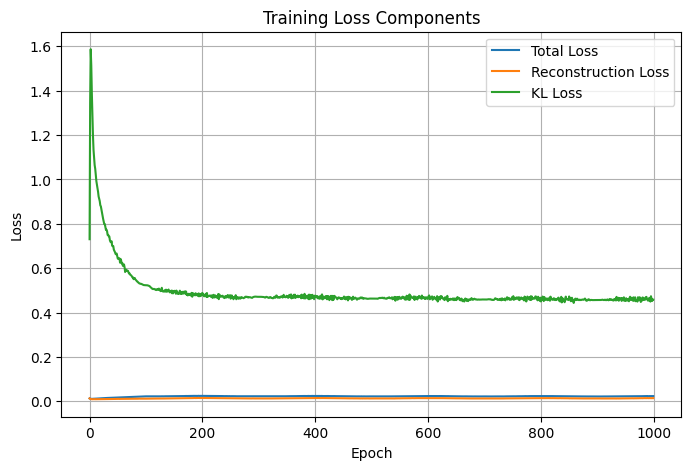

In [55]:
#plotting three losses
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history, label="Total Loss")
plt.plot(recon_history, label="Reconstruction Loss")
plt.plot(kl_history, label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Components")
plt.legend()
plt.grid(True)
plt.show()

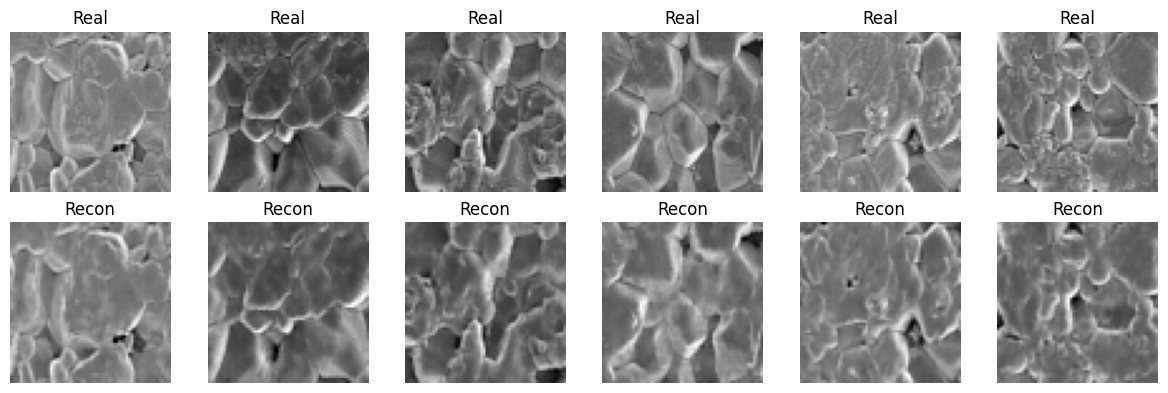

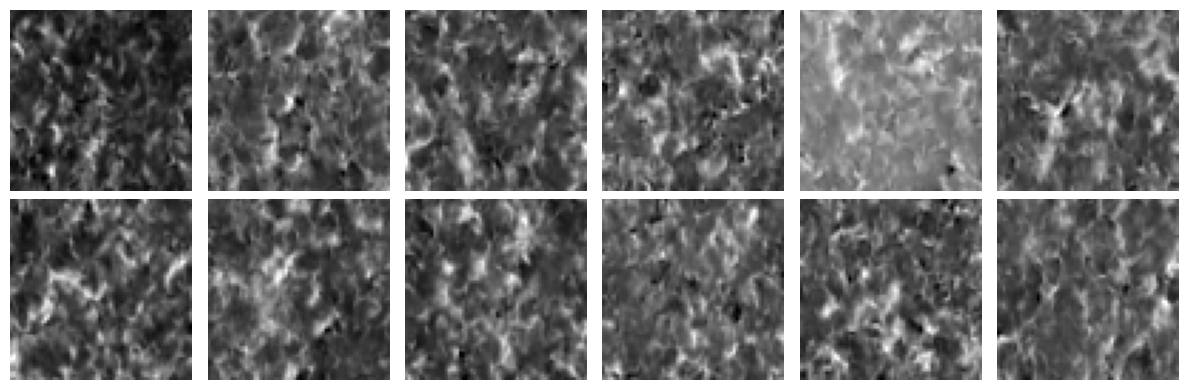

In [56]:
# to show reconstructions
model.eval()
x_dino, x_target = next(iter(loader))
x_dino = x_dino.to(DEVICE)
x_target = x_target.to(DEVICE)

with torch.no_grad():
    feat = dino(x_dino)
    recon, _, _ = model(feat)

x_target = x_target.cpu()
recon = recon.cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(x_target[i, 0], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title("Real")

    axes[1, i].imshow(recon[i, 0], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title("Recon")
plt.tight_layout()
plt.show()

# =========================================================
# Generate NEW images
# =========================================================
with torch.no_grad():
    z = torch.randn(12, LATENT_DIM).to(DEVICE)
    samples = model.decode(z).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(12):
    axes[i // 6, i % 6].imshow(samples[i, 0], cmap="gray")
    axes[i // 6, i % 6].axis("off")
plt.tight_layout()
plt.show()

In [57]:
def compute_mae(recon, target):
   
    #MAE = Mean Absolute Error
    #similar to L1 loss, averaged over all pixels.
    #Lower is better.
    return F.l1_loss(recon, target, reduction="mean")

In [58]:
def compute_mse(recon, target):
    # MSE = Mean Squared Error
    # It penalizes larger pixel errors more strongly than MAE.
    #Lower is better.
    return F.mse_loss(recon, target, reduction="mean")

In [59]:
#PSNR = Peak Signal-to-Noise Ratio-> to see reconstruction quality
#higher psnr better reconstruction
def compute_psnr(recon, target, data_range=1.0):
    mse = F.mse_loss(recon, target, reduction="mean")

    # If MSE is exactly 0, PSNR becomes infinite.
    # We protect against division-by-zero just in case.
    if mse.item() == 0:
        return torch.tensor(float("inf"), device=recon.device)

    psnr = 10 * torch.log10((data_range ** 2) / mse)
    return psnr

In [60]:
#x_dino -> DINO -> feature embedding -> VAE -> recon-> compute the metrics: 
#MAE, MSE, PSNR, SSIM
def evaluate_reconstruction(model, dino, loader, device):
    model.eval()
    dino.eval()

    # SSIM object
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    total_mae = 0.0
    total_mse = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    total_samples = 0

    with torch.no_grad():
        for x_dino, x_target in loader:
            x_dino = x_dino.to(device)
            x_target = x_target.to(device)

            #get frozen DINO features
            feat = dino(x_dino)

            #reconstruct through your VAE model
            recon, mu, logvar = model(feat)

            # Batch size for weighted averaging
            batch_size = x_target.size(0)

            # Compute reconstruction metrics for this batch
            mae_val = compute_mae(recon, x_target)
            mse_val = compute_mse(recon, x_target)
            psnr_val = compute_psnr(recon, x_target)
            ssim_val = ssim_metric(recon, x_target)

            # Accumulate weighted sums
            total_mae += mae_val.item() * batch_size
            total_mse += mse_val.item() * batch_size
            total_psnr += psnr_val.item() * batch_size
            total_ssim += ssim_val.item() * batch_size
            total_samples += batch_size

    #Final averages across the full dataset
    results = {
        "MAE_L1": total_mae / total_samples,
        "MSE": total_mse / total_samples,
        "PSNR": total_psnr / total_samples,
        "SSIM": total_ssim / total_samples,
    }

    return results

In [61]:
#FID: compares distribution of fake images with real images
#lower is better
"""
    FID expects images in uint8 format with 3 channels.
    images are grayscale in [0, 1], shape [B, 1, H, W].
    steps
      1. Repeat channel 1 -> 3 channels
      2. scale [0,1] -> [0,255]
      3. convert to uint8
    Output shape:
      [B, 3, H, W], dtype=torch.uint8
    """
def prepare_for_fid(x):
    
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)

    x = (x * 255.0).clamp(0, 255).to(torch.uint8)
    return x

In [62]:
#Computes FID between->real target images from dataset
#FID for generated images
def evaluate_fid_generated(model, loader, latent_dim, device, num_fake_samples=None):

    model.eval()

    fid_metric = FrechetInceptionDistance(feature=2048).to(device)

    total_real_seen = 0

    with torch.no_grad():
        for _, x_target in loader:
            x_target = x_target.to(device)
            batch_size = x_target.size(0)

            # -------------------------------
            # Real images
            # -------------------------------
            real_fid = prepare_for_fid(x_target)
            fid_metric.update(real_fid, real=True)

            # -------------------------------
            # Fake images from random z
            # -------------------------------
            z = torch.randn(batch_size, latent_dim).to(device)
            fake = model.decode(z)

            fake_fid = prepare_for_fid(fake)
            fid_metric.update(fake_fid, real=False)

            total_real_seen += batch_size

            # Optional stopping condition
            if num_fake_samples is not None and total_real_seen >= num_fake_samples:
                break

    fid_score = fid_metric.compute().item()
    return fid_score

In [63]:
#    This version computes FID between->real target images vs.reconstructed images
#how close reconstructed images to the real image distribution
def evaluate_fid_reconstruction(model, dino, loader, device):

    model.eval()
    dino.eval()

    fid_metric = FrechetInceptionDistance(feature=2048).to(device)

    with torch.no_grad():
        for x_dino, x_target in loader:
            x_dino = x_dino.to(device)
            x_target = x_target.to(device)

            feat = dino(x_dino)
            recon, _, _ = model(feat)

            real_fid = prepare_for_fid(x_target)
            recon_fid = prepare_for_fid(recon)

            fid_metric.update(real_fid, real=True)
            fid_metric.update(recon_fid, real=False)

    fid_score = fid_metric.compute().item()
    return fid_score

In [64]:
from torchmetrics.image.fid import FrechetInceptionDistance
fid_recon = evaluate_fid_reconstruction(model, dino, loader, DEVICE)
print(fid_recon)

78.64047241210938


In [65]:
recon_results = evaluate_reconstruction(model, dino, loader, DEVICE)
print(recon_results)

{'MAE_L1': 0.01355997545337214, 'MSE': 0.000351537958813777, 'PSNR': 34.55053281321109, 'SSIM': 0.9150398853913094}


In [66]:
fid_generated = evaluate_fid_generated(model, loader, latent_dim=64, device=DEVICE)
print(fid_generated)

401.9267578125
